In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot

In [2]:
df=pd.read_csv("tech_job_market_2019_2026.csv")
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [3]:
df.shape

(115000, 28)

In [4]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


float datatype=4
int datatype=3
string datatype =21

In [6]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

# conclusions
- there are missing values in columns,but they are very few to be dropped

In [7]:
df.duplicated().sum()

np.int64(1193)

In [8]:
print(df[df.duplicated()])

           job_id              company_name company_type       sector  \
1584    JOB002656              DriftGame Co          MNC       EdTech   
2216    JOB000563              NexusCompute   FAANG-tier  Crypto/Web3   
2969    JOB073226               BeaconPixel          MNC  Cloud/Infra   
3897    JOB022039            BeaconStack Co          MNC        AI/ML   
4327    JOB006733           SummitShield Co     Mid-size   E-commerce   
...           ...                       ...          ...          ...   
114639  JOB110813            BeaconStack Co          MNC        AI/ML   
114824  JOB100893           AnchorBuzz Labs          MNC   HealthTech   
114866  JOB110283              CobaltWealth          MNC   HealthTech   
114871  JOB035395               AetherAI Co          MNC        AI/ML   
114982  JOB006051  LumenArcade Technologies          MNC    Logistics   

        company_size_employees hq_country                   job_role  \
1584                    156326        USA          

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()   

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


#### minimum value of number of applicants is -5,that could be a data entry error

## univariate analysis

In [12]:
print((df['number_of_applicants']<0).sum())

243


### making these values nan 

In [13]:
df.loc[df['number_of_applicants']<0,'number_of_applicants']=np.nan

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_4768\1793824347.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sector',data=df, palette='hls')


<Axes: xlabel='count', ylabel='sector'>

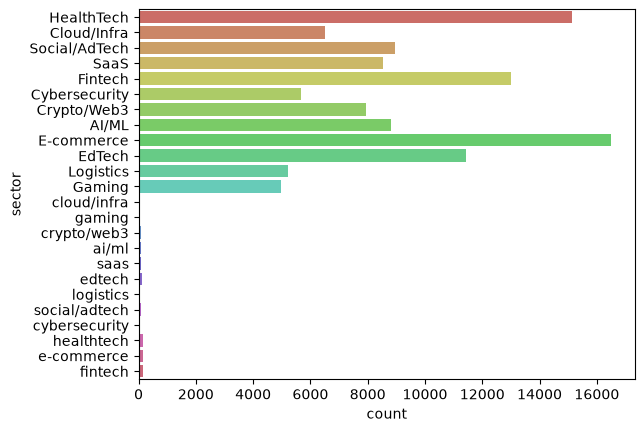

In [14]:
sns.countplot(y='sector',data=df, palette='hls')

there are repeated sector due to case senstivity

In [15]:
df['sector'].value_counts()

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

In [16]:
df['sector']=df['sector'].str.upper()

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_4768\3788966777.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sector',data=df, palette='hls')


<Axes: xlabel='count', ylabel='sector'>

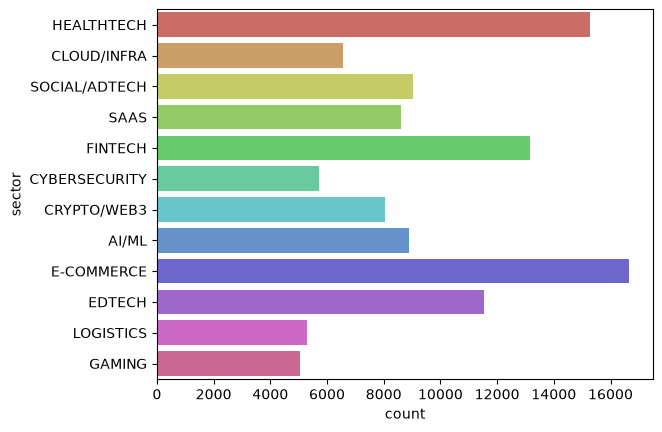

In [17]:
sns.countplot(y='sector',data=df, palette='hls')


In [18]:
df['company_name'].value_counts()

company_name
NexusShield            3228
MeridianToken          3173
RidgeFreight Labs      3084
SpireCloud             3000
AetherAI Co            2720
                       ... 
AETHERCOGNITION           1
  MeridianReach Inc       1
NovaArcade Co             1
  SpireHub Inc            1
CATALYSTCONNECT CO        1
Name: count, Length: 898, dtype: int64

In [19]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

job_id: 113000 unique values
company_name: 898 unique values
company_type: 5 unique values
sector: 12 unique values
company_size_employees: 75225 unique values
hq_country: 13 unique values
job_role: 160 unique values
seniority_level: 6 unique values
years_experience_min: 21 unique values
years_experience_max: 21 unique values
required_tech_stack: 29271 unique values
primary_programming_language: 15 unique values
work_mode: 13 unique values
visa_sponsorship_offered: 8 unique values
job_location_country: 13 unique values
job_location_city: 41 unique values
salary_currency: 10 unique values
posting_date: 2638 unique values
application_deadline: 2843 unique values
date_position_filled: 2791 unique values
position_status: 4 unique values
number_of_applicants: 1652 unique values
number_of_interview_rounds: 8 unique values
offers_extended: 9 unique values
offers_accepted: 11 unique values
salary_min_usd: 4795 unique values
salary_max_usd: 4157 unique values
layoff_within_12_months_flag: 8 uni

In [20]:
df['job_role'].value_counts()   

job_role
Backend Engineer             5939
Embedded Systems Engineer    5912
QA Engineer                  5854
Software Engineer            5820
Frontend Engineer            5786
                             ... 
 QA Engineer                    1
 FRONTEND ENGINEER              1
 Data Analyst                   1
 Mobile Engineer (iOS)          1
 DATA ENGINEER                  1
Name: count, Length: 160, dtype: int64

## analysis
- some job role are listed multiple times due to case senstivity

In [21]:
df['job_role']=df['job_role'].str.upper()

In [22]:
df['job_role'].value_counts()

job_role
BACKEND ENGINEER             6022
EMBEDDED SYSTEMS ENGINEER    5986
QA ENGINEER                  5930
SOFTWARE ENGINEER            5882
FRONTEND ENGINEER            5865
                             ... 
PRODUCT DESIGNER                8
PENETRATION TESTER              4
 QA ENGINEER                    1
 DATA ANALYST                   1
 MOBILE ENGINEER (IOS)          1
Name: count, Length: 96, dtype: int64

## analysis 
- job_role reduced to 96 unique values from 160

In [23]:
df['work_mode'].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

## analysis
- same work_mode is listed multiple time due to case_senstivity

In [24]:
df['work_mode']=df['work_mode'].str.lower()

In [25]:
df['work_mode'].value_counts()

work_mode
hybrid            51243
remote            33127
onsite            27405
work from home      560
wfh                 556
in-office           461
on-site             455
Name: count, dtype: int64

In [26]:
df['work_mode']=df['work_mode'].str.replace('work from home','wfh')
df['work_mode']=df['work_mode'].str.replace('on-site','onsite')
df['work_mode'].value_counts()

work_mode
hybrid       51243
remote       33127
onsite       27860
wfh           1116
in-office      461
Name: count, dtype: int64

<Axes: xlabel='work_mode', ylabel='count'>

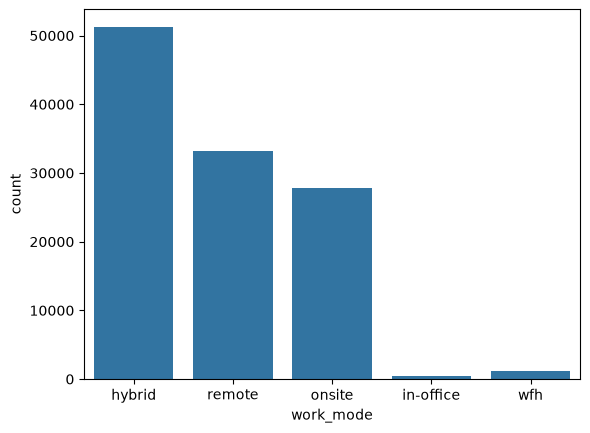

In [27]:
sns.countplot(x='work_mode', data=df)

 # Analysis
 - most of the jobs offer hybrid,remote working oppurtunity

In [28]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0        19625
False    19555
N        19553
No       19346
Yes       9001
True      8937
1         8897
Y         8893
Name: count, dtype: int64

- binary catogorical field having multiple inputs from true false value

In [29]:
df['visa_sponsorship_offered']=df['visa_sponsorship_offered'].replace({"False": 0,"No": 0,"N":0,"True": 1,"Yes": 1,"Y":1,"0":0,"1":1})

In [30]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0    78079
1    35728
Name: count, dtype: int64

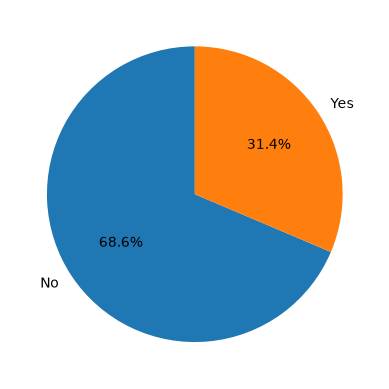

In [31]:
plot.pie(df['visa_sponsorship_offered'].value_counts(), labels=['No', 'Yes'], startangle=90,autopct='%1.1f%%')

In [32]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
N        24905
0        24736
False    24717
No       24526
Y         3785
Yes       3759
1         3734
True      3645
Name: count, dtype: int64

In [33]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({"False": 0,"No": 0,"N":0,"True": 1,"Yes": 1,"Y":1,"0":0,"1":1})

In [34]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
0    98884
1    14923
Name: count, dtype: int64

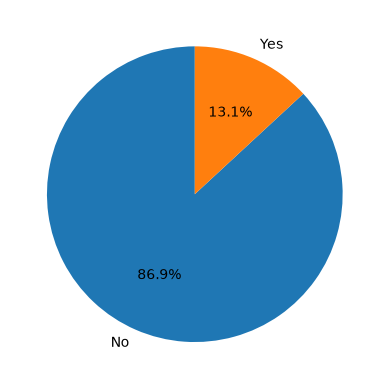

In [35]:
plot.pie(df['layoff_within_12_months_flag'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)

# bivariate analysis

<Axes: >

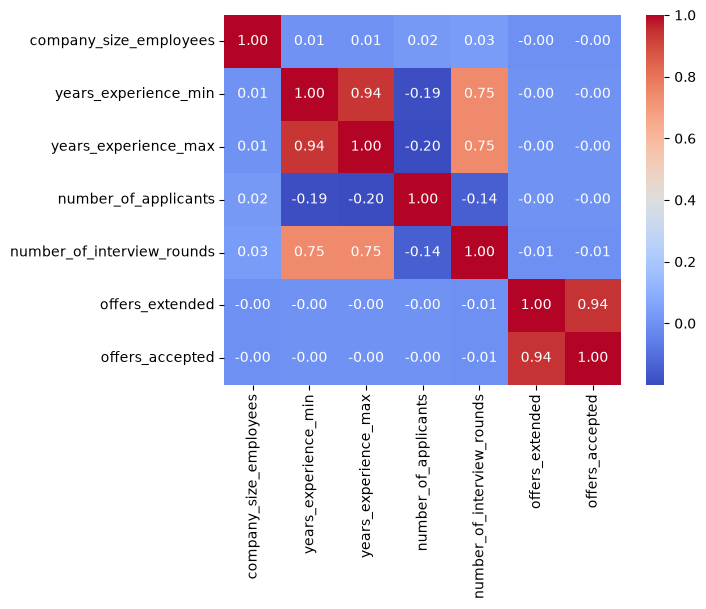

In [36]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

## relation analysis
- offers_extended and offers_accepted have 0.94 correlation index
- number_of_interview_rounds have corelation of 0.75 with years_experience_min,max
- years_experience_min and years_experience_max have 0.94 correlation index

<Axes: xlabel='offers_extended', ylabel='offers_accepted'>

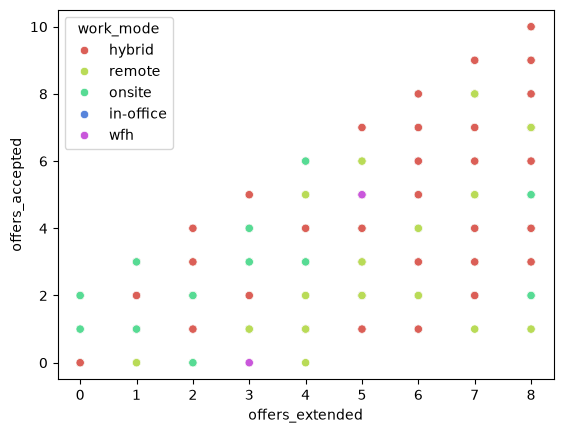

In [37]:
sns.scatterplot(x='offers_extended', y='offers_accepted', data=df, hue='work_mode', palette='hls')

## plot analysis
- offers_accepted exceeds offers_extended at some locations

In [38]:
(df['offers_accepted'] > df['offers_extended']).value_counts()

False    113216
True        591
Name: count, dtype: int64

In [39]:
df2 = df[df['offers_accepted'] > df['offers_extended']]
print(df2[['position_status', 'offers_extended', 'offers_accepted']].where(df2['offers_extended'] == 0).dropna().value_counts())

position_status  offers_extended  offers_accepted
Withdrawn        0.0              1.0                14
Cancelled        0.0              1.0                13
Withdrawn        0.0              2.0                11
Cancelled        0.0              2.0                 9
Name: count, dtype: int64


## analysis
- we can reduce offers_accepted to 0 where offers_extended==0

In [40]:
df.loc[df['offers_extended'] == 0, 'offers_accepted'] = 0

In [41]:
df2 = df[df['offers_accepted'] > df['offers_extended']]
print(df2[['position_status', 'offers_extended', 'offers_accepted']].value_counts())

position_status  offers_extended  offers_accepted
Filled           1.0              2.0                210
                                  3.0                199
Open             1.0              2.0                 28
                                  3.0                 14
Cancelled        1.0              3.0                  8
Filled           8.0              9.0                  7
                 7.0              8.0                  7
                 5.0              6.0                  6
                 2.0              3.0                  6
                 7.0              9.0                  5
                 3.0              5.0                  5
                 4.0              5.0                  4
Withdrawn        1.0              3.0                  4
                                  2.0                  4
Filled           2.0              4.0                  3
                 6.0              8.0                  3
Open             3.0              4.0 

# analysis
- since we dont know about job_vacancies,we cannot amend the data inconsistency
- there are chances that offer was cancelled/withdrawn after offers_extended or offers_accepted

In [42]:
df[['hq_country','job_location_country','salary_currency']].value_counts()

hq_country   job_location_country  salary_currency
USA          USA                   USD                31847
India        India                 INR                16572
UK           UK                    GBP                13310
Germany      Germany               EUR                 6153
Canada       Canada                CAD                 5336
                                                      ...  
Israel       UAE                   AED                    8
Netherlands  Ireland               EUR                    7
Ireland      Netherlands           EUR                    6
             Brazil                BRL                    4
             UAE                   AED                    3
Name: count, Length: 169, dtype: int64

In [43]:
print(df[df['posting_date'] > df['application_deadline']])

Empty DataFrame
Columns: [job_id, company_name, company_type, sector, company_size_employees, hq_country, job_role, seniority_level, years_experience_min, years_experience_max, required_tech_stack, primary_programming_language, work_mode, visa_sponsorship_offered, job_location_country, job_location_city, salary_currency, posting_date, application_deadline, date_position_filled, position_status, number_of_applicants, number_of_interview_rounds, offers_extended, offers_accepted, salary_min_usd, salary_max_usd, layoff_within_12_months_flag]
Index: []

[0 rows x 28 columns]


### there is no inconsistency in posting and application_deadline dates

In [44]:
df['offer_accept_ratio'] = df['offers_accepted'] / df['offers_extended']

<Axes: xlabel='offer_accept_ratio', ylabel='Density'>

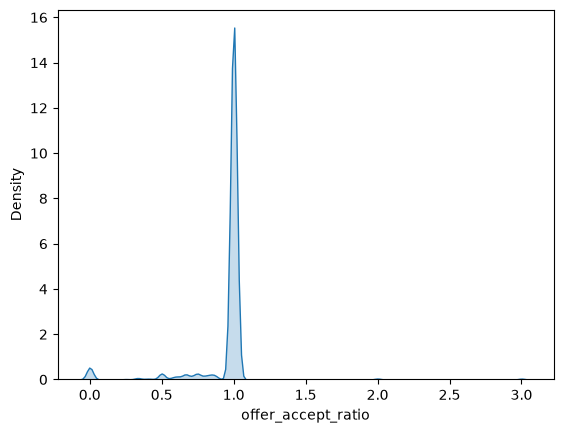

In [45]:
sns.kdeplot(df['offer_accept_ratio'].dropna(), fill=True)

# analysis
- Generally most of the offers were accepted

In [46]:
df[['hq_country','job_location_country','visa_sponsorship_offered','work_mode']].value_counts()

hq_country  job_location_country  visa_sponsorship_offered  work_mode
USA         USA                   0                         hybrid       7597
                                  1                         hybrid       6739
India       India                 0                         hybrid       6451
USA         USA                   0                         remote       5024
                                  1                         remote       4291
                                                                         ... 
Israel      Canada                1                         onsite          1
Brazil      UK                    0                         wfh             1
Australia   Singapore             1                         onsite          1
            Brazil                1                         in-office       1
Ireland     UAE                   0                         onsite          1
Name: count, Length: 1086, dtype: int64

In [47]:
print(df[df['years_experience_min'] > df['years_experience_max']])


           job_id               company_name company_type      sector  \
131     JOB031986             DriftSkill Inc          MNC  E-COMMERCE   
133     JOB089059             CatalystHub Co      Unicorn       AI/ML   
679     JOB101867    NimbusGame Technologies     Mid-size      EDTECH   
1943    JOB011486                FusionTrade          MNC     FINTECH   
2301    JOB101144                FusionTrade          MNC     FINTECH   
...           ...                        ...          ...         ...   
113800  JOB018427            VertexBlock Inc          MNC      GAMING   
114117  JOB069657  TideSentinel Technologies      Unicorn  HEALTHTECH   
114292  JOB023878                AetherAI Co          MNC       AI/ML   
114629  JOB085791              MeridianToken          MNC      EDTECH   
114875  JOB109662        EchoFreight Systems   FAANG-tier        SAAS   

        company_size_employees hq_country                   job_role  \
131                     126266     Canada  MOBILE E

## analysis
- there are 315 rows where years_experience_min > years_experience_max
- high possibility that records got swapped while entry

therefore we can swap values

In [48]:
mask=df['years_experience_min'] > df['years_experience_max']
df.loc[mask, ['years_experience_min','years_experience_max']] = df.loc[mask, ['years_experience_max', 'years_experience_min']].values

<Axes: xlabel='company_size_employees', ylabel='company_type'>

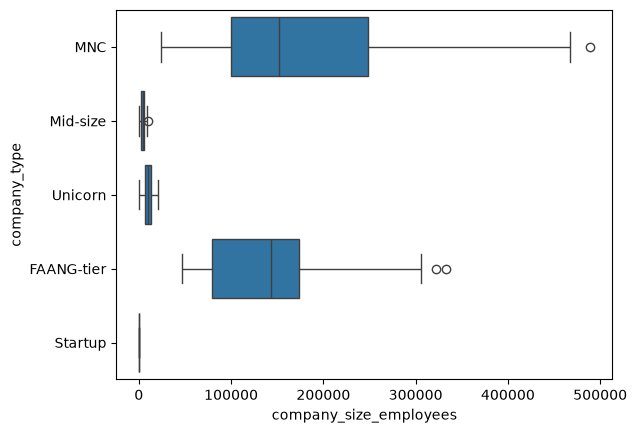

In [49]:
sns.boxplot(x='company_size_employees',y='company_type', data=df)

In [50]:
df['year']=pd.to_datetime(df['posting_date']).dt.year

<Axes: xlabel='year', ylabel='number_of_applicants'>

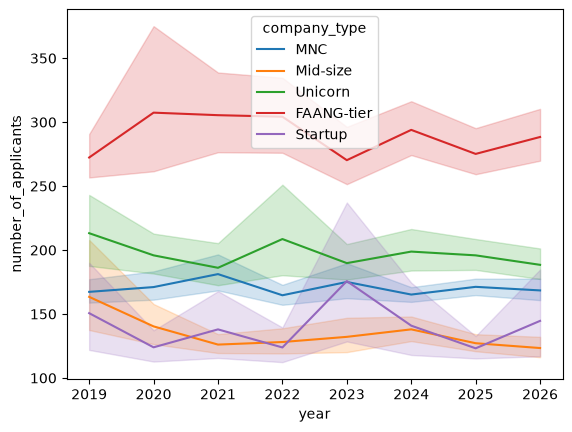

In [51]:
sns.lineplot(x='year', y='number_of_applicants', hue='company_type', data=df)

# Conclusions
- Most job postings were from the sector of Healthcare,E-commerce,Fintech
- There are 96 job roles listed across sector 
- hybrid and remote work_mode were prominent in job_postings across 2019-2026
- 31% of the total job postings sponsered visa of the applicants
- layoff within a year was saturated at approx 13%
- 